Install dependencies.

In [1]:
!pip install -q econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 13.0 MB/s eta 0:00:00


Load the analysis-ready dataset and set up imports.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

DATA_DIR = '/content'
df = pd.read_csv(f'{DATA_DIR}/analysis_ready.csv')
print(f'Loaded {len(df):,} firms')

Loaded 14,139 firms


Build the control matrix (53 features).

In [3]:
sector_dummies = pd.get_dummies(df['nace_section'], prefix='sec', drop_first=True)
country_dummies = pd.get_dummies(df['country'], prefix='ctry', drop_first=True)
indep_dummies = pd.get_dummies(df['independence'], prefix='indep', drop_first=True)
cohort_dummies = pd.get_dummies(df['first_grant_year'], prefix='cohort', drop_first=True)

numeric_cols = ['log_rev_pre', 'log_emp_pre', 'log_assets_pre', 'pm_pre', 'offset']

X_all = pd.concat(
    [df[numeric_cols], country_dummies, sector_dummies, indep_dummies, cohort_dummies],
    axis=1)
X_all.columns = X_all.columns.astype(str)

print(f'Control matrix: {X_all.shape[1]} features')
print(f'  Numeric: {len(numeric_cols)}')
print(f'  Country: {country_dummies.shape[1]}')
print(f'  Sector: {sector_dummies.shape[1]}')
print(f'  Independence: {indep_dummies.shape[1]}')
print(f'  Cohort: {cohort_dummies.shape[1]}')

Control matrix: 53 features
  Numeric: 5
  Country: 15
  Sector: 20
  Independence: 3
  Cohort: 10


Define the analysis samples.

In [4]:
controls_ok = X_all.notna().all(axis=1) & df['nace_2d'].notna()
keep_rev = df['rev_growth'].notna() & df['log_ec'].notna() & controls_ok
keep_emp = df['emp_growth'].notna() & df['log_ec'].notna() & controls_ok

ht_cols = ['ht_oecd', 'ht_calvino', 'ht_pavitt', 'ht_pavitt_broad']
ht_labels = ['OECD', 'Calvino', 'Pavitt narrow', 'Pavitt broad']

print(f'Revenue sample:    {keep_rev.sum():,}')
print(f'Employment sample: {keep_emp.sum():,}')

Revenue sample:    3,750
Employment sample: 3,497


High-tech shares across the full sample, by each definition.

In [5]:
print('High-tech share (full sample, N = {:,}):'.format(len(df)))
for col, label in zip(ht_cols, ht_labels):
    share = df[col].mean()
    n = df[col].sum()
    print(f'  {label:15s}  {share:5.1%}  ({n:,} firms)')

High-tech share (full sample, N = 14,139):
  OECD             30.2%  (4,269 firms)
  Calvino          49.3%  (6,972 firms)
  Pavitt narrow    32.1%  (4,536 firms)
  Pavitt broad     61.7%  (8,725 firms)


High-tech shares by funding instrument, with chi-squared tests of independence.

In [6]:
instruments = ['SME', 'Collaborative', 'Early-stage']
mask_inst = df['primary_instrument'].isin(instruments)

for col, label in zip(ht_cols, ht_labels):
    ct = pd.crosstab(df.loc[mask_inst, 'primary_instrument'], df.loc[mask_inst, col])
    chi2, p, dof, _ = chi2_contingency(ct)

    shares = df.loc[mask_inst].groupby('primary_instrument')[col].mean()
    parts = '  '.join(f'{inst}: {shares[inst]:.1%}' for inst in instruments)
    print(f'{label:15s}  {parts}  |  chi2={chi2:.1f}, p={p:.2e}')

print()
print('Contingency table (last definition shown):')
print(ct)

OECD             SME: 43.7%  Collaborative: 26.5%  Early-stage: 47.6%  |  chi2=331.0, p=1.34e-72
Calvino          SME: 52.0%  Collaborative: 48.2%  Early-stage: 53.0%  |  chi2=13.7, p=1.07e-03
Pavitt narrow    SME: 45.8%  Collaborative: 28.3%  Early-stage: 50.1%  |  chi2=333.7, p=3.45e-73
Pavitt broad     SME: 72.9%  Collaborative: 58.8%  Early-stage: 72.4%  |  chi2=169.1, p=1.92e-37

Contingency table (last definition shown):
ht_pavitt_broad        0     1
primary_instrument            
Collaborative       4501  6425
Early-stage          188   493
SME                  500  1346


High-tech shares by ownership status, with chi-squared tests of independence.

In [7]:
ownership = ['Independent', 'Subsidiary']
mask_own = df['independence'].isin(ownership)

for col, label in zip(ht_cols, ht_labels):
    ct = pd.crosstab(df.loc[mask_own, 'independence'], df.loc[mask_own, col])
    chi2, p, dof, _ = chi2_contingency(ct)

    shares = df.loc[mask_own].groupby('independence')[col].mean()
    parts = '  '.join(f'{o}: {shares[o]:.1%}' for o in ownership)
    print(f'{label:15s}  {parts}  |  chi2={chi2:.1f}, p={p:.2e}')

OECD             Independent: 42.6%  Subsidiary: 27.1%  |  chi2=107.7, p=3.18e-25
Calvino          Independent: 55.9%  Subsidiary: 44.3%  |  chi2=50.0, p=1.52e-12
Pavitt narrow    Independent: 43.5%  Subsidiary: 29.8%  |  chi2=81.0, p=2.27e-19
Pavitt broad     Independent: 69.9%  Subsidiary: 60.5%  |  chi2=34.3, p=4.75e-09


Bar charts of high-tech shares: overall, by instrument, and by ownership.

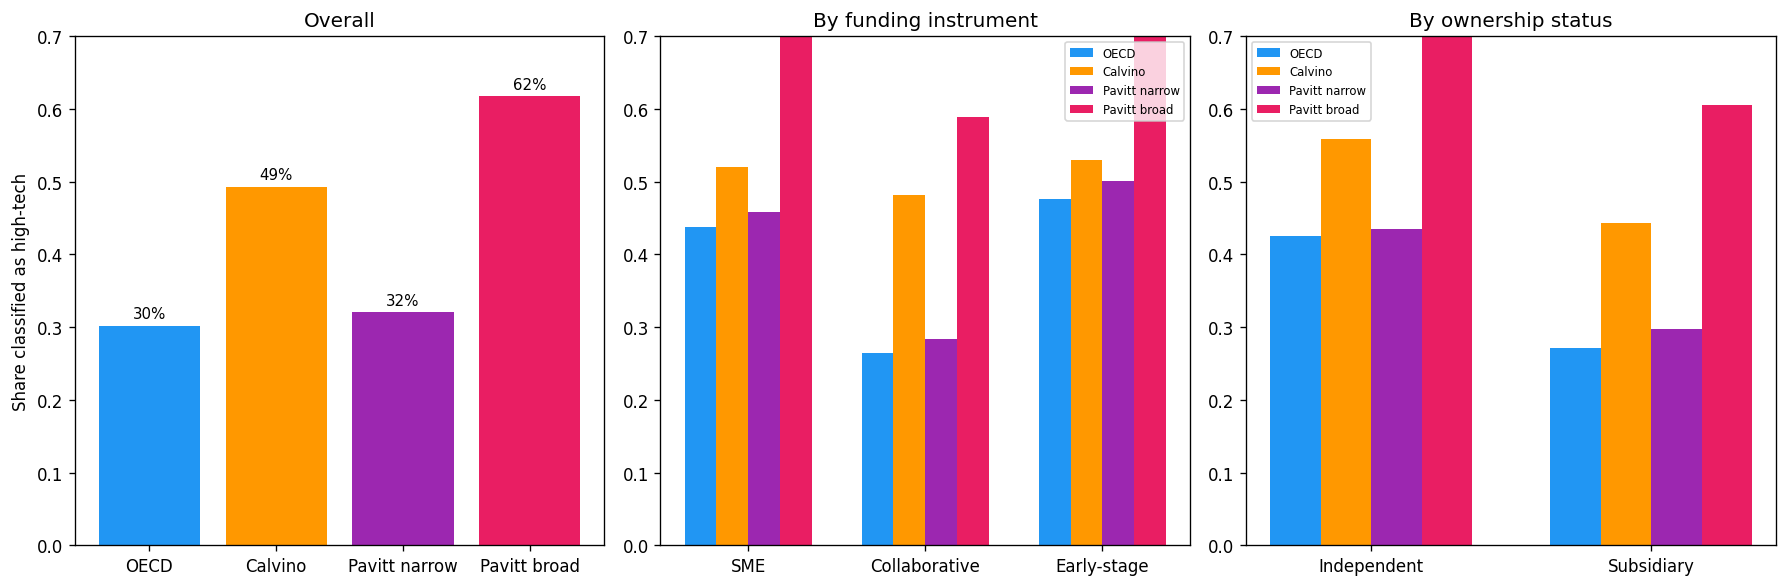

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2196F3', '#FF9800', '#9C27B0', '#E91E63']

# Overall
shares = [df[c].mean() for c in ht_cols]
axes[0].bar(ht_labels, shares, color=colors)
axes[0].set_ylabel('Share classified as high-tech')
axes[0].set_title('Overall')
axes[0].set_ylim(0, 0.7)
for i, v in enumerate(shares):
    axes[0].text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=9)

# By instrument
instruments = ['SME', 'Collaborative', 'Early-stage']
x = np.arange(len(instruments))
w = 0.18
for i, (col, label) in enumerate(zip(ht_cols, ht_labels)):
    vals = [df.loc[df['primary_instrument'] == inst, col].mean() for inst in instruments]
    axes[1].bar(x + i * w, vals, w, label=label, color=colors[i])
axes[1].set_xticks(x + 1.5 * w)
axes[1].set_xticklabels(instruments)
axes[1].set_title('By funding instrument')
axes[1].set_ylim(0, 0.7)
axes[1].legend(fontsize=7)

# By ownership
ownership = ['Independent', 'Subsidiary']
x = np.arange(len(ownership))
for i, (col, label) in enumerate(zip(ht_cols, ht_labels)):
    vals = [df.loc[df['independence'] == o, col].mean() for o in ownership]
    axes[2].bar(x + i * w, vals, w, label=label, color=colors[i])
axes[2].set_xticks(x + 1.5 * w)
axes[2].set_xticklabels(ownership)
axes[2].set_title('By ownership status')
axes[2].set_ylim(0, 0.7)
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/ht_shares.png', dpi=150, bbox_inches='tight')
plt.show()

Define the DML estimation function.

In [9]:
def run_dml(Y, T, X_base, ht_indicator):
    X = np.column_stack([X_base, ht_indicator.reshape(-1, 1)])

    est = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=200, min_samples_leaf=30, n_jobs=-1, random_state=42),
        model_t=RandomForestRegressor(
            n_estimators=200, min_samples_leaf=30, n_jobs=-1, random_state=42),
        n_estimators=200,
        min_samples_leaf=30,
        random_state=42,
        cv=5
    )
    est.fit(Y, T, X=X)

    def scalar(x):
        return float(np.asarray(x).flat[0])

    # Overall ATE with built-in inference
    inf = est.ate_inference(X=X)
    ate = scalar(inf.mean_point)
    ate_se = scalar(inf.stderr_mean)
    if hasattr(inf, 'conf_int_mean'):
        ci = inf.conf_int_mean()
    else:
        ci = inf.conf_int()
    ate_ci_lo, ate_ci_hi = scalar(ci[0]), scalar(ci[1])
    if hasattr(inf, 'pvalue'):
        try:
            ate_pval = scalar(inf.pvalue())
        except TypeError:
            ate_pval = scalar(inf.pvalue)
    else:
        from scipy.stats import norm
        ate_pval = 2 * norm.sf(abs(ate / ate_se)) if ate_se > 0 else 1.0

    # Firm-level CATEs for the high-tech premium
    cate = est.effect(X).flatten()
    ht_mask = ht_indicator == 1
    n_ht = int(ht_mask.sum())
    n_non_ht = int((~ht_mask).sum())

    mean_ht = float(cate[ht_mask].mean())
    mean_non_ht = float(cate[~ht_mask].mean())
    se_ht = float(cate[ht_mask].std(ddof=1) / np.sqrt(n_ht))
    se_non_ht = float(cate[~ht_mask].std(ddof=1) / np.sqrt(n_non_ht))
    premium = mean_ht - mean_non_ht
    premium_se = float(np.sqrt(se_ht**2 + se_non_ht**2))

    return {
        'ate': ate, 'ate_se': ate_se,
        'ate_ci_lo': ate_ci_lo, 'ate_ci_hi': ate_ci_hi, 'ate_pval': ate_pval,
        'mean_ht': mean_ht, 'mean_non_ht': mean_non_ht,
        'se_ht': se_ht, 'se_non_ht': se_non_ht,
        'premium': premium, 'premium_se': premium_se,
        'premium_ci_lo': premium - 1.96 * premium_se,
        'premium_ci_hi': premium + 1.96 * premium_se,
        'n_total': len(Y), 'n_ht': n_ht, 'n_non_ht': n_non_ht,
    }

print('DML estimation function defined.')

DML estimation function defined.


Run all 48 DML specifications across subgroups, outcomes, and definitions.

In [10]:
subgroups = [
    ('Overall', None, None),
    ('SME', 'primary_instrument', 'SME'),
    ('Collaborative', 'primary_instrument', 'Collaborative'),
    ('Early-stage', 'primary_instrument', 'Early-stage'),
    ('Independent', 'independence', 'Independent'),
    ('Subsidiary', 'independence', 'Subsidiary'),
]

all_results = []

for sg_name, filt_col, filt_val in subgroups:
    for out_name, out_col, mask in [('Revenue', 'rev_growth', keep_rev),
                                     ('Employment', 'emp_growth', keep_emp)]:
        sub_mask = mask if filt_col is None else mask & (df[filt_col] == filt_val)
        n = sub_mask.sum()
        if n < 100:
            print(f'Skipping {sg_name} | {out_name}: n={n}')
            continue

        Y = df.loc[sub_mask, out_col].values
        T = df.loc[sub_mask, 'log_ec'].values
        X = X_all.loc[sub_mask].values

        for ht_col, ht_label in zip(ht_cols, ht_labels):
            ht = df.loc[sub_mask, ht_col].values
            if ht.sum() < 30 or (1 - ht).sum() < 30:
                print(f'Skipping {sg_name} | {out_name} | {ht_label}: thin cell')
                continue

            print(f'{sg_name} | {out_name} | {ht_label} (n={n})')
            res = run_dml(Y, T, X, ht)
            res.update({'subgroup': sg_name, 'outcome': out_name, 'definition': ht_label})
            all_results.append(res)
            print(f'  ATE={res["ate"]:.4f} (p={res["ate_pval"]:.3f}), '
                  f'premium={res["premium"]:.4f} +/- {res["premium_se"]:.4f}')

results_df = pd.DataFrame(all_results)
print(f'\nCompleted {len(results_df)} specifications.')

Overall | Revenue | OECD (n=3750)
  ATE=0.0305 (p=0.282), premium=0.0241 +/- 0.0007
Overall | Revenue | Calvino (n=3750)
  ATE=0.0305 (p=0.272), premium=0.0083 +/- 0.0007
Overall | Revenue | Pavitt narrow (n=3750)
  ATE=0.0302 (p=0.273), premium=0.0159 +/- 0.0007
Overall | Revenue | Pavitt broad (n=3750)
  ATE=0.0309 (p=0.260), premium=0.0108 +/- 0.0006
Overall | Employment | OECD (n=3497)
  ATE=0.0287 (p=0.113), premium=0.0128 +/- 0.0006
Overall | Employment | Calvino (n=3497)
  ATE=0.0276 (p=0.132), premium=0.0062 +/- 0.0005
Overall | Employment | Pavitt narrow (n=3497)
  ATE=0.0285 (p=0.126), premium=0.0101 +/- 0.0006
Overall | Employment | Pavitt broad (n=3497)
  ATE=0.0284 (p=0.119), premium=0.0075 +/- 0.0005
SME | Revenue | OECD (n=292)
  ATE=0.1399 (p=0.006), premium=0.0056 +/- 0.0014
SME | Revenue | Calvino (n=292)
  ATE=0.1398 (p=0.007), premium=0.0057 +/- 0.0013
SME | Revenue | Pavitt narrow (n=292)
  ATE=0.1400 (p=0.006), premium=0.0017 +/- 0.0014
SME | Revenue | Pavitt broa

Overall ATE results.

In [11]:
overall = results_df[results_df['subgroup'] == 'Overall']

print('Overall Average Treatment Effect (log grant size on log growth):')
print(f'{"Outcome":12s} | {"Definition":14s} | {"ATE":>7s} | {"SE":>6s} | {"95% CI":>20s} | {"p":>5s}')
print('-' * 75)
for _, r in overall.iterrows():
    print(f'{r["outcome"]:12s} | {r["definition"]:14s} | {r["ate"]:7.4f} | {r["ate_se"]:6.4f} | '
          f'[{r["ate_ci_lo"]:8.4f}, {r["ate_ci_hi"]:8.4f}] | {r["ate_pval"]:5.3f}')

Overall Average Treatment Effect (log grant size on log growth):
Outcome      | Definition     |     ATE |     SE |               95% CI |     p
---------------------------------------------------------------------------
Revenue      | OECD           |  0.0305 | 0.0283 | [ -0.0251,   0.0860] | 0.282
Revenue      | Calvino        |  0.0305 | 0.0278 | [ -0.0239,   0.0849] | 0.272
Revenue      | Pavitt narrow  |  0.0302 | 0.0276 | [ -0.0238,   0.0843] | 0.273
Revenue      | Pavitt broad   |  0.0309 | 0.0275 | [ -0.0229,   0.0848] | 0.260
Employment   | OECD           |  0.0287 | 0.0181 | [ -0.0068,   0.0642] | 0.113
Employment   | Calvino        |  0.0276 | 0.0183 | [ -0.0083,   0.0635] | 0.132
Employment   | Pavitt narrow  |  0.0285 | 0.0186 | [ -0.0080,   0.0651] | 0.126
Employment   | Pavitt broad   |  0.0284 | 0.0182 | [ -0.0073,   0.0642] | 0.119


High-tech premium with approximate standard errors (independence assumption).

In [12]:
print(f'{"Subgroup":14s} | {"Outcome":10s} | {"Def.":14s} | '
      f'{"Premium":>8s} | {"SE":>6s} | {"95% CI":>20s} | {"n_HT":>5s} | {"n_other":>5s}')
print('-' * 105)
for _, r in results_df.iterrows():
    print(f'{r["subgroup"]:14s} | {r["outcome"]:10s} | {r["definition"]:14s} | '
          f'{r["premium"]:8.4f} | {r["premium_se"]:6.4f} | '
          f'[{r["premium_ci_lo"]:8.4f}, {r["premium_ci_hi"]:8.4f}] | '
          f'{r["n_ht"]:5d} | {r["n_non_ht"]:5d}')

n_pos = (results_df['premium'] > 0).sum()
print(f'\nPositive premium: {n_pos}/{len(results_df)} ({n_pos/len(results_df):.0%})')
print(f'Median premium: {results_df["premium"].median():.4f}')
print(f'Max absolute premium: {results_df["premium"].abs().max():.4f}')

Subgroup       | Outcome    | Def.           |  Premium |     SE |               95% CI |  n_HT | n_other
---------------------------------------------------------------------------------------------------------
Overall        | Revenue    | OECD           |   0.0241 | 0.0007 | [  0.0228,   0.0254] |   869 |  2881
Overall        | Revenue    | Calvino        |   0.0083 | 0.0007 | [  0.0070,   0.0095] |  1433 |  2317
Overall        | Revenue    | Pavitt narrow  |   0.0159 | 0.0007 | [  0.0146,   0.0172] |   980 |  2770
Overall        | Revenue    | Pavitt broad   |   0.0108 | 0.0006 | [  0.0096,   0.0121] |  1984 |  1766
Overall        | Employment | OECD           |   0.0128 | 0.0006 | [  0.0118,   0.0139] |   828 |  2669
Overall        | Employment | Calvino        |   0.0062 | 0.0005 | [  0.0052,   0.0073] |  1338 |  2159
Overall        | Employment | Pavitt narrow  |   0.0101 | 0.0006 | [  0.0090,   0.0112] |   925 |  2572
Overall        | Employment | Pavitt broad   |   0.0075 | 0.

ATE results by subgroup.

In [13]:
for sg in results_df['subgroup'].unique():
    sub = results_df[results_df['subgroup'] == sg]
    print(f'\n--- {sg} (n = {sub["n_total"].iloc[0]:,}) ---')
    for _, r in sub.iterrows():
        sig = '*' if r['ate_pval'] < 0.05 else ''
        print(f'  {r["outcome"]:10s} | {r["definition"]:14s} | '
              f'ATE={r["ate"]:7.4f}{sig:1s} (p={r["ate_pval"]:.3f}) | '
              f'HT mean={r["mean_ht"]:7.4f} | non-HT mean={r["mean_non_ht"]:7.4f} | '
              f'premium={r["premium"]:7.4f}')


--- Overall (n = 3,750) ---
  Revenue    | OECD           | ATE= 0.0305  (p=0.282) | HT mean= 0.0490 | non-HT mean= 0.0249 | premium= 0.0241
  Revenue    | Calvino        | ATE= 0.0305  (p=0.272) | HT mean= 0.0356 | non-HT mean= 0.0274 | premium= 0.0083
  Revenue    | Pavitt narrow  | ATE= 0.0302  (p=0.273) | HT mean= 0.0420 | non-HT mean= 0.0261 | premium= 0.0159
  Revenue    | Pavitt broad   | ATE= 0.0309  (p=0.260) | HT mean= 0.0360 | non-HT mean= 0.0252 | premium= 0.0108
  Employment | OECD           | ATE= 0.0287  (p=0.113) | HT mean= 0.0385 | non-HT mean= 0.0257 | premium= 0.0128
  Employment | Calvino        | ATE= 0.0276  (p=0.132) | HT mean= 0.0315 | non-HT mean= 0.0253 | premium= 0.0062
  Employment | Pavitt narrow  | ATE= 0.0285  (p=0.126) | HT mean= 0.0360 | non-HT mean= 0.0258 | premium= 0.0101
  Employment | Pavitt broad   | ATE= 0.0284  (p=0.119) | HT mean= 0.0320 | non-HT mean= 0.0245 | premium= 0.0075

--- SME (n = 292) ---
  Revenue    | OECD           | ATE= 0.1399*

Definition sensitivity: standard deviation of the premium across the four definitions.

In [14]:
print(f'{"Subgroup":14s} | {"Outcome":10s} | {"Std":>6s} | {"Min":>8s} | {"Max":>8s} | {"Range":>8s}')
print('-' * 70)
for sg in results_df['subgroup'].unique():
    for out in results_df['outcome'].unique():
        s = results_df[(results_df['subgroup'] == sg) & (results_df['outcome'] == out)]
        if len(s) > 1:
            print(f'{sg:14s} | {out:10s} | {s["premium"].std():.4f} | '
                  f'{s["premium"].min():8.4f} | {s["premium"].max():8.4f} | '
                  f'{s["premium"].max() - s["premium"].min():8.4f}')

Subgroup       | Outcome    |    Std |      Min |      Max |    Range
----------------------------------------------------------------------
Overall        | Revenue    | 0.0070 |   0.0083 |   0.0241 |   0.0158
Overall        | Employment | 0.0029 |   0.0062 |   0.0128 |   0.0066
SME            | Revenue    | 0.0021 |   0.0017 |   0.0057 |   0.0040
SME            | Employment | 0.0018 |   0.0017 |   0.0056 |   0.0039
Collaborative  | Revenue    | 0.0105 |   0.0049 |   0.0265 |   0.0215
Collaborative  | Employment | 0.0023 |   0.0002 |   0.0057 |   0.0055
Early-stage    | Revenue    | 0.0000 |   0.0000 |   0.0000 |   0.0000
Early-stage    | Employment | 0.0000 |  -0.0000 |   0.0000 |   0.0000
Independent    | Revenue    | 0.0021 |  -0.0029 |   0.0011 |   0.0040
Independent    | Employment | 0.0032 |   0.0024 |   0.0093 |   0.0069
Subsidiary     | Revenue    | 0.0009 |   0.0001 |   0.0020 |   0.0019
Subsidiary     | Employment | 0.0007 |   0.0005 |   0.0020 |   0.0015


Specification curve: the high-tech premium across all specifications, sorted by size.

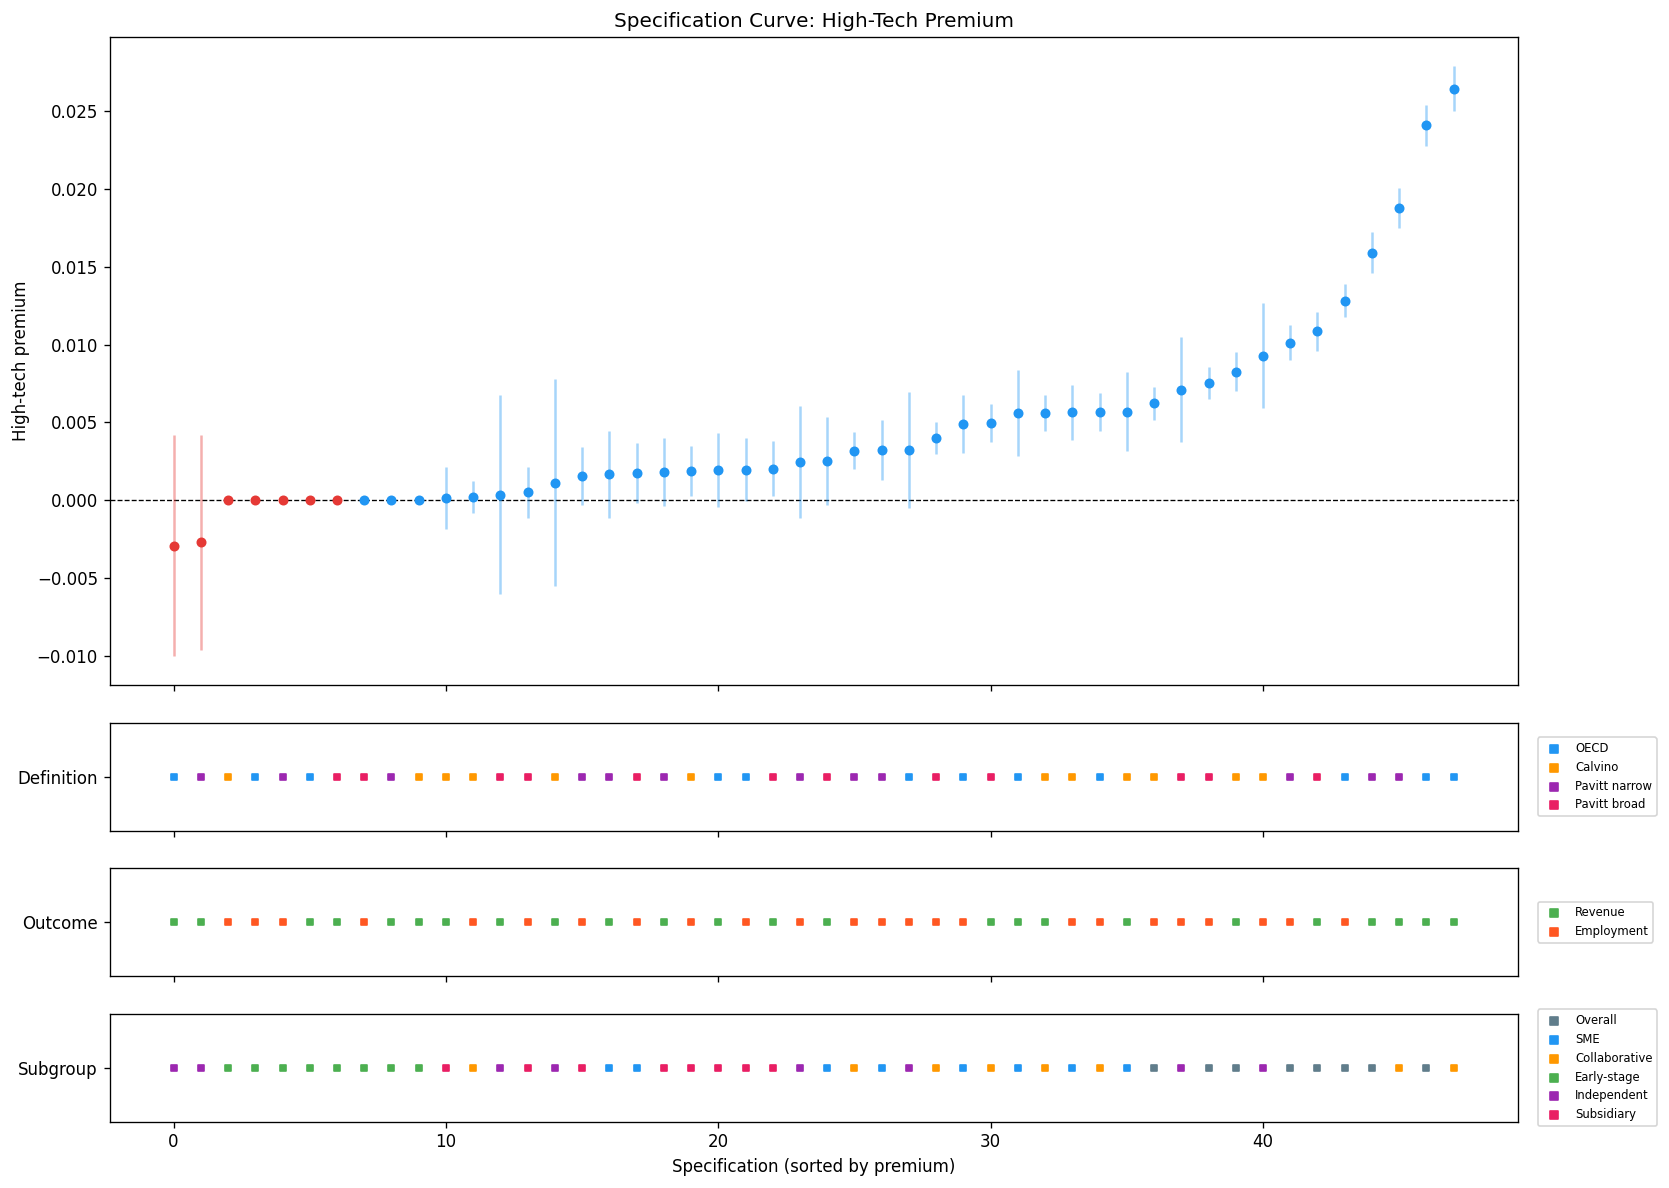

In [15]:
spec = results_df.sort_values('premium').reset_index(drop=True)
spec['x'] = range(len(spec))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1, figsize=(14, 10),
    gridspec_kw={'height_ratios': [3, 0.5, 0.5, 0.5]}, sharex=True)

# Top panel: premium point estimates and CIs
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
for _, r in spec.iterrows():
    c = '#2196F3' if r['premium'] > 0 else '#E53935'
    ax1.plot(r['x'], r['premium'], 'o', color=c, markersize=5)
    ax1.vlines(r['x'], r['premium_ci_lo'], r['premium_ci_hi'],
               color=c, alpha=0.4, linewidth=1.5)
ax1.set_ylabel('High-tech premium')
ax1.set_title('Specification Curve: High-Tech Premium')

# Indicator rows
def indicator_row(ax, data, column, cmap):
    for _, r in data.iterrows():
        ax.scatter(r['x'], 0, color=cmap.get(r[column], 'gray'), s=15, marker='s')
    ax.set_yticks([0])
    ax.set_yticklabels([column.capitalize()])
    for cat, col in cmap.items():
        ax.scatter([], [], color=col, label=cat, s=20, marker='s')
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=7)

indicator_row(ax2, spec, 'definition',
    {'OECD': '#2196F3', 'Calvino': '#FF9800', 'Pavitt narrow': '#9C27B0', 'Pavitt broad': '#E91E63'})
indicator_row(ax3, spec, 'outcome',
    {'Revenue': '#4CAF50', 'Employment': '#FF5722'})
indicator_row(ax4, spec, 'subgroup',
    {'Overall': '#607D8B', 'SME': '#2196F3', 'Collaborative': '#FF9800',
     'Early-stage': '#4CAF50', 'Independent': '#9C27B0', 'Subsidiary': '#E91E63'})

ax4.set_xlabel('Specification (sorted by premium)')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/specification_curve.png', dpi=150, bbox_inches='tight')
plt.show()

ATE by subgroup, averaged across definitions.

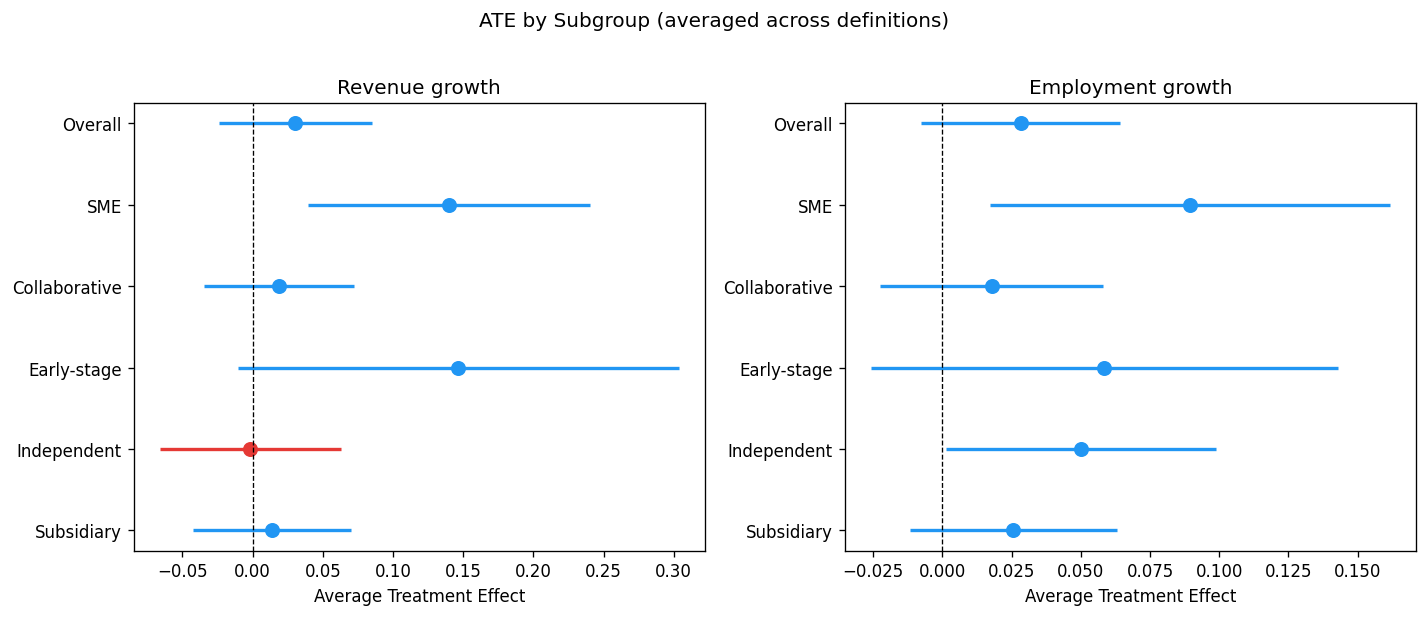

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sg_order = ['Overall', 'SME', 'Collaborative', 'Early-stage', 'Independent', 'Subsidiary']

for idx, outcome in enumerate(['Revenue', 'Employment']):
    ax = axes[idx]
    for i, sg in enumerate(sg_order):
        s = results_df[(results_df['subgroup'] == sg) & (results_df['outcome'] == outcome)]
        if len(s) == 0:
            continue
        ate_mean = s['ate'].mean()
        ate_lo = s['ate_ci_lo'].mean()
        ate_hi = s['ate_ci_hi'].mean()
        c = '#2196F3' if ate_mean > 0 else '#E53935'
        ax.plot(ate_mean, i, 'o', color=c, markersize=8)
        ax.hlines(i, ate_lo, ate_hi, color=c, linewidth=2)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(len(sg_order)))
    ax.set_yticklabels(sg_order)
    ax.set_xlabel('Average Treatment Effect')
    ax.set_title(f'{outcome} growth')
    ax.invert_yaxis()

plt.suptitle('ATE by Subgroup (averaged across definitions)', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/ate_by_subgroup.png', dpi=150, bbox_inches='tight')
plt.show()

Save all results.

In [17]:
results_df.to_csv(f'{DATA_DIR}/dml_results.csv', index=False)
print(f'Saved {len(results_df)} results to dml_results.csv')

Saved 48 results to dml_results.csv
